In [1]:
import nocd
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import normalize

%matplotlib inline

# Hapus atau komentari baris ini jika tidak ada GPU (CUDA)
# torch.set_default_tensor_type(torch.cuda.FloatTensor)

### Playground Wijdan
1. Ubah dataset .tsv menjadi .npz biar ngikutin repo ini

In [3]:
import pandas as pd
import networkx as nx
import numpy as np
from scipy import sparse

# 1. Baca data
edges = pd.read_csv("dataset/string_kanker_ginjal.tsv", sep="\t", comment=None)

# 2. Buat graph
G = nx.from_pandas_edgelist(edges, source='#node1', target='node2', edge_attr='combined_score')

# 3. Konversi ke adjacency matrix (sparse)
A = nx.to_scipy_sparse_array(G, dtype=np.float32)  # adjacency matrix dalam bentuk sparse

# 4. Simpan ke file
sparse.save_npz("kanker_ginjal_adj.npz", A)
np.savez("dataset/kanker_ginjal_graph.npz", A=A)

# 5. Kasih Info aja
print("Berhasil dibuat .npz ada di folder dataset/")


Berhasil dibuat .npz ada di folder dataset/


2. Make Sure kalo datanya dah sesuai

In [60]:
data = np.load("dataset/kanker_ginjal_graph.npz")
print(data.files)

print(type(A))
print(A.shape)
print(A.nnz)

print("------")

data1 = np.load("data/mag_cs.npz")
print(data1.files)

print(type(data1['adj_matrix.data']))


['A']
<class 'scipy.sparse._csr.csr_matrix'>
(21957, 21957)
193500
------
['adj_matrix.data', 'adj_matrix.indices', 'adj_matrix.indptr', 'adj_matrix.shape', 'attr_matrix.data', 'attr_matrix.indices', 'attr_matrix.indptr', 'attr_matrix.shape', 'edge_attr_matrix', 'labels.data', 'labels.indices', 'labels.indptr', 'labels.shape', 'node_names', 'attr_names', 'edge_attr_names', 'class_names', 'metadata', 'type']
<class 'numpy.ndarray'>


3. Ambil contoh dataset, terus ubah jadi xlsx atau csv atau tsv \
Untuk nyamain sama dataset milik ku

In [36]:
import numpy as np
import pandas as pd

# 1. Tentukan path file
file_npz = 'dataset/string_kanker_ginjal.npz'

try:
    # Load file .npz
    # allow_pickle=True mungkin diperlukan tergantung bagaimana file npz dibuat
    data = np.load(file_npz, allow_pickle=True)

    # --- LANGKAH 1: INSPEKSI KEYS ---
    keys = list(data.keys())
    print(f"✅ File {file_npz} berhasil dimuat.")
    print(f"Ditemukan keys (nama array) berikut di dalam file:")
    
    # Cetak semua keys dan bentuk (shape) dari array
    for i, key in enumerate(keys):
        array_shape = data[key].shape
        print(f"{i+1}. Key: '{key}', Shape: {array_shape}")
    
    # --- LANGKAH 2 & 3: KONVERSI KE XLSX DAN CSV ---
    
    # ASUMSI: Array yang ingin dikonversi memiliki key 'data'
    selected_key = 'data'
    
    if selected_key in keys:
        print(f"\n⚙️ Melanjutkan konversi array dengan key '{selected_key}'...")
        
        # Konversi ke Pandas DataFrame
        df = pd.DataFrame(data[selected_key])
        
        # Simpan ke XLSX
        file_xlsx = 'data/dataset_ini.xlsx'
        # Gunakan 'index=False' agar nomor baris DataFrame tidak ikut tersimpan
        df.to_excel(file_xlsx, index=False) 
        print(f"✅ Berhasil menyimpan array '{selected_key}' ke format XLSX: {file_xlsx}")
        
        # Simpan ke CSV
        file_csv = 'data/dataset_ini.csv'
        df.to_csv(file_csv, index=False)
        print(f"✅ Berhasil menyimpan array '{selected_key}' ke format CSV: {file_csv}")
        
    elif keys:
        print(f"\n⚠️ Key '{selected_key}' tidak ditemukan. Harap ubah baris kode 'selected_key = \"data\"' menjadi salah satu key yang tercantum di atas (misalnya: '{keys[0]}') dan jalankan ulang skrip.")
        
    else:
        print("\n❌ File .npz tidak mengandung array data.")

except FileNotFoundError:
    print(f"❌ ERROR: File tidak ditemukan di path: {file_npz}")
    print("Pastikan file 'dataset_ini.npz' berada di dalam folder 'data' relatif terhadap lokasi skrip Python Anda.")

except Exception as e:
    print(f"❌ Terjadi error saat memproses file: {e}")

✅ File dataset/string_kanker_ginjal.npz berhasil dimuat.
Ditemukan keys (nama array) berikut di dalam file:
1. Key: 'adj_matrix', Shape: ()
2. Key: 'adj_matrix_data', Shape: (3226,)
3. Key: 'adj_matrix_indices', Shape: (3226,)
4. Key: 'adj_matrix_indptr', Shape: (440,)
5. Key: 'adj_matrix_shape', Shape: (2,)
6. Key: 'attr_matrix', Shape: ()
7. Key: 'attr_matrix_data', Shape: (439,)
8. Key: 'attr_matrix_indices', Shape: (439,)
9. Key: 'attr_matrix_indptr', Shape: (440,)
10. Key: 'attr_matrix_shape', Shape: (2,)
11. Key: 'labels', Shape: ()
12. Key: 'labels_data', Shape: (0,)
13. Key: 'labels_indices', Shape: (0,)
14. Key: 'labels_indptr', Shape: (440,)
15. Key: 'labels_shape', Shape: (2,)
16. Key: 'node_names', Shape: (439,)
17. Key: 'class_names', Shape: (20,)
18. Key: 'attr_names', Shape: (439,)

⚠️ Key 'data' tidak ditemukan. Harap ubah baris kode 'selected_key = "data"' menjadi salah satu key yang tercantum di atas (misalnya: 'adj_matrix') dan jalankan ulang skrip.


In [37]:
import numpy as np
import pandas as pd

# 1. Tentukan path file
file_npz = 'dataset/string_kanker_ginjal.npz' # Nama file sudah disesuaikan
file_xlsx = 'dataset/test.xlsx' # Nama output file

try:
    data = np.load(file_npz, allow_pickle=True)
    
    # # Daftar keys yang ingin dikonversi menjadi sheet di Excel
    # keys_to_export = ['adj_matrix.data', 'adj_matrix.indices', 'adj_matrix.indptr', 'adj_matrix.shape', 'attr_matrix.data','attr_matrix.indices', 'attr_matrix.indptr', 'attr_matrix.shape', 'labels.data', 'labels.indices', 'labels.indptr', 'labels.shape']
    keys_to_export = ['node_names', 'class_names', 'attr_names']
    
    print(f"⚙️ Memproses file {file_npz} dan menyimpan ke {file_xlsx}...")

    # Gunakan Pandas ExcelWriter untuk menyimpan banyak sheet dalam satu file
    with pd.ExcelWriter(file_xlsx, engine='openpyxl') as writer:
        
        for key in keys_to_export:
            if key in data.keys():
                # Data 'node_names' dan 'attr_names' memiliki shape (N,)
                # Kita perlu mengubahnya menjadi DataFrame 1 kolom
                
                # Konversi array NumPy menjadi Pandas Series, lalu ke DataFrame
                df = pd.DataFrame(data[key], columns=[key]) 
                
                # Simpan ke sheet Excel. Ganti karakter yang tidak diizinkan di nama sheet.
                sheet_name = key.replace('.', '_')
                df.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"✅ Berhasil menyimpan array '{key}' ke sheet: '{sheet_name}'")
            else:
                print(f"⚠️ Key '{key}' tidak ditemukan. Melewati.")
                
    print(f"\n🎉 Konversi Selesai! File Excel output berada di: {file_xlsx}")

except FileNotFoundError:
    print(f"❌ ERROR: File tidak ditemukan di path: {file_npz}")

except Exception as e:
    print(f"❌ Terjadi error saat memproses file: {e}")
    
# --- Penanganan Data Sparse (Opsional Lanjutan) ---
# Jika Anda ingin melihat 'attr_matrix', diperlukan konversi dari format CSR/CSC ke dense matrix,
# yang bisa menghabiskan banyak RAM jika matriksnya sangat besar (63282 x 5538).
# Contoh (JANGAN DICOBA jika RAM Anda terbatas):
# attr_matrix_sparse = data['attr_matrix']
# attr_matrix_dense = attr_matrix_sparse.todense()
# df_attr = pd.DataFrame(attr_matrix_dense)

⚙️ Memproses file dataset/string_kanker_ginjal.npz dan menyimpan ke dataset/test.xlsx...
✅ Berhasil menyimpan array 'node_names' ke sheet: 'node_names'
✅ Berhasil menyimpan array 'class_names' ke sheet: 'class_names'
✅ Berhasil menyimpan array 'attr_names' ke sheet: 'attr_names'

🎉 Konversi Selesai! File Excel output berada di: dataset/test.xlsx


In [31]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import os

# --- KONFIGURASI ---
FILE_NPZ = 'data/mag_med.npz'
N_ROWS = 100 # Batasan Baris
OUTPUT_DIR = 'dataset'
FILE_A = os.path.join(OUTPUT_DIR, 'dataset_check_A.xlsx') # Adjacency (Interaksi)
FILE_B = os.path.join(OUTPUT_DIR, 'dataset_check_B.xlsx') # Fitur (Attribute)
FILE_C = os.path.join(OUTPUT_DIR, 'dataset_check_C.xlsx') # Label

# Buat folder output jika belum ada
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"✅ Folder '{OUTPUT_DIR}' dibuat.")

try:
    # 1. Muat Data NPZ
    data_npz = np.load(FILE_NPZ, allow_pickle=True)
    print(f"✅ File {FILE_NPZ} berhasil dimuat.")

    # 2. Ambil Data Nama Langsung dari NPZ
    # Menggunakan .tolist() untuk mengkonversi array numpy 1D menjadi list Python
    df_nodes = data_npz['node_names'].tolist()
    df_attrs = data_npz['attr_names'].tolist()
    df_classes = data_npz['class_names'].tolist()
    print(f"✅ Nama Node, Atribut, dan Kelas berhasil diekstrak dari NPZ.")

    # --- FUNGSI BANTU UNTUK REKONSTRUKSI MATRIKS SPARSE ---
    def reconstruct_sparse_matrix(key_prefix, data_source):
        """Membangun kembali matriks sparse dari komponen NPZ keys."""
        data = data_source[f'{key_prefix}.data']
        indices = data_source[f'{key_prefix}.indices']
        indptr = data_source[f'{key_prefix}.indptr']
        shape = data_source[f'{key_prefix}.shape']
        return csr_matrix((data, indices, indptr), shape=shape)

    # --- A. MATRIKS INTERAKSI (ADJACENCY) -> dataset_check_A.xlsx ---
    # Interaksi lebih baik divisualisasikan sebagai daftar edge (edge list)
    print("\n--- Memproses A: Matriks Interaksi (Edge List) ---")
    adj_matrix_sparse = reconstruct_sparse_matrix('adj_matrix', data_npz)
    
    # Ambil 100 baris pertama (koneksi dari 100 node pertama)
    adj_subset = adj_matrix_sparse[:N_ROWS].tocoo()
    
    df_adj = pd.DataFrame({
        'Source_Index': adj_subset.row,
        'Target_Index': adj_subset.col,
        'Weight': adj_subset.data
    })
    
    # Ubah indeks menjadi nama Node ID agar mudah dibaca
    df_adj['Source_Node_ID'] = df_adj['Source_Index'].apply(lambda i: df_nodes[i])
    df_adj['Target_Node_ID'] = df_adj['Target_Index'].apply(lambda i: df_nodes[i])
    df_adj = df_adj[['Source_Node_ID', 'Target_Node_ID', 'Weight']]

    df_adj.to_excel(FILE_A, index=False)
    print(f"✅ Berhasil menyimpan Matriks Interaksi ke: {FILE_A}")

    # --- B. MATRIKS FITUR (ATTRIBUTE) -> dataset_check_B.xlsx ---
    print("\n--- Memproses B: Matriks Fitur ---")
    attr_matrix_sparse = reconstruct_sparse_matrix('attr_matrix', data_npz)
    
    # Ambil 100 baris pertama dan konversi ke DataFrame
    df_attr = pd.DataFrame(
        attr_matrix_sparse[:N_ROWS].todense(),
        columns=df_attrs # Nama kolom: attr_names
    )
    df_attr.index = df_nodes[:N_ROWS]
    df_attr.index.name = 'Node_ID'

    df_attr.to_excel(FILE_B)
    print(f"✅ Berhasil menyimpan Matriks Fitur (100 baris) ke: {FILE_B}")
    
    # --- C. MATRIKS LABEL -> dataset_check_C.xlsx ---
    print("\n--- Memproses C: Matriks Label ---")
    labels_matrix_sparse = reconstruct_sparse_matrix('labels', data_npz)
    
    # Ambil 100 baris pertama dan konversi ke DataFrame
    df_labels = pd.DataFrame(
        labels_matrix_sparse[:N_ROWS].todense(),
        columns=df_classes # Nama kolom: class_names
    )
    df_labels.index = df_nodes[:N_ROWS]
    df_labels.index.name = 'Node_ID'

    df_labels.to_excel(FILE_C)
    print(f"✅ Berhasil menyimpan Matriks Label (100 baris) ke: {FILE_C}")
    
    print("\n🎉 Semua konversi dan ekspor selesai. Silakan cek folder 'dataset/'.")
    
except FileNotFoundError as e:
    print(f"❌ ERROR: File tidak ditemukan. Pastikan file '{FILE_NPZ}' berada di lokasi yang benar (di dalam folder 'data/'). Detail: {e}")
except Exception as e:
    print(f"❌ Terjadi error tak terduga: {e}")

✅ File data/mag_med.npz berhasil dimuat.
✅ Nama Node, Atribut, dan Kelas berhasil diekstrak dari NPZ.

--- Memproses A: Matriks Interaksi (Edge List) ---
✅ Berhasil menyimpan Matriks Interaksi ke: dataset\dataset_check_A.xlsx

--- Memproses B: Matriks Fitur ---
✅ Berhasil menyimpan Matriks Fitur (100 baris) ke: dataset\dataset_check_B.xlsx

--- Memproses C: Matriks Label ---
✅ Berhasil menyimpan Matriks Label (100 baris) ke: dataset\dataset_check_C.xlsx

🎉 Semua konversi dan ekspor selesai. Silakan cek folder 'dataset/'.


In [ ]:
import pandas as pd
import os

def konversi_tsv_ke_xlsx(input_path, output_path):
    """
    Mengubah file TSV menjadi XLSX, termasuk memastikan folder output ada.

    Args:
        input_path (str): Path lengkap file TSV input (misalnya, 'dataset/data.tsv').
        output_path (str): Path lengkap file XLSX output (misalnya, 'dataset/data.xlsx').
    """
    
    # Dapatkan direktori dari path output
    output_dir = os.path.dirname(output_path)
    
    # 1. Pastikan direktori output ada
    if output_dir and not os.path.exists(output_dir):
        print(f"Membuat direktori: {output_dir}")
        os.makedirs(output_dir, exist_ok=True)
    
    print(f"Membaca file TSV: {input_path}...")
    
    try:
        # 2. Baca file TSV menggunakan pandas
        # sep='\t' digunakan karena ini adalah Tab-Separated Values
        df = pd.read_csv(input_path, sep='\t')
        
        # 3. Tulis DataFrame ke file XLSX
        # index=False agar indeks/nomor baris pandas tidak ikut ditulis di Excel
        print(f"Menulis ke file XLSX: {output_path}...") 
        df.to_excel(output_path, index=False)
        
        print("\n✅ Konversi selesai!")
        print(f"File output telah disimpan sebagai: {output_path}")
        
    except FileNotFoundError:
        print(f"\n❌ ERROR: File input '{input_path}' tidak ditemukan.")
    except Exception as e:
        print(f"\n❌ Terjadi kesalahan saat konversi: {e}")

# --- PENGGUNAAN SKRIP ---
file_input = 'dataset/string_kanker_ginjal.tsv'
file_output = 'dataset/string_kanker_ginjal.xlsx'

# Panggil fungsi konversi
konversi_tsv_ke_xlsx(file_input, file_output)

Membaca file TSV: dataset/string_kanker_ginjal.tsv...
Menulis ke file XLSX: dataset/string_kanker_ginjal.xlsx...

✅ Konversi selesai!
File output telah disimpan sebagai: dataset/string_kanker_ginjal.xlsx


In [4]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, identity

# --- 1. LOAD DATA DAN BUAT MAPPING NODE ---
# Pastikan 'string_kanker_ginjal.xlsx' ada di direktori kerja
df = pd.read_excel('dataset/string_kanker_ginjal.xlsx')
df.columns = df.columns.str.replace('#', '') # Bersihkan #node1

nodes = pd.unique(df[['node1', 'node2']].values.ravel())
N = len(nodes)
node_map = {name: i for i, name in enumerate(nodes)}

# --- 2. BUAT ADJACENCY MATRIX (A) ---
source = df['node1'].map(node_map).values
target = df['node2'].map(node_map).values
weight = df['combined_score'].values

# Buat matriks simetris (interaksi dua arah)
data_A = np.concatenate([weight, weight])
row_A = np.concatenate([source, target])
col_A = np.concatenate([target, source])

adj_matrix = csr_matrix((data_A, (row_A, col_A)), shape=(N, N))

# --- 3. BUAT FEATURE MATRIX (X) DUMMY ---
# Matriks Identitas sebagai fitur (N x N)
attr_matrix = identity(N, format='csr')

# --- 4. BUAT LABEL MATRIX (Z) DUMMY ---
# Placeholder untuk 20 komunitas (C=20). Semua bernilai 0
C = 20
labels = csr_matrix((N, C), dtype=np.float32)

# --- 5. SIMPAN KE FORMAT .NPZ DENGAN NAMA KEY YANG BENAR (menggunakan TITIK '.') ---
# Simpan semua komponen sparse
np.savez_compressed('dataset/string_kanker_ginjal.npz',
    # KOREKSI: Mengganti underscore (_) dengan titik (.)
    
    # Komponen Adjacency (A)
    **{'adj_matrix.data': adj_matrix.data,
       'adj_matrix.indices': adj_matrix.indices,
       'adj_matrix.indptr': adj_matrix.indptr,
       'adj_matrix.shape': adj_matrix.shape},
    
    # Komponen Fitur (X)
    **{'attr_matrix.data': attr_matrix.data,
       'attr_matrix.indices': attr_matrix.indices,
       'attr_matrix.indptr': attr_matrix.indptr,
       'attr_matrix.shape': attr_matrix.shape},
    
    # Komponen Label (Z)
    **{'labels.data': labels.data,
       'labels.indices': labels.indices,
       'labels.indptr': labels.indptr,
       'labels.shape': labels.shape},

    # Tambahan data untuk kompatibilitas
    node_names=nodes,
    class_names=np.array([f'community_{i}' for i in range(C)]),
    attr_names=np.array([f'feature_{i}' for i in range(N)]), 
)
print("✅ File 'data/string_kanker_ginjal.npz' berhasil dibuat dengan KEY yang benar.")

✅ File 'data/string_kanker_ginjal.npz' berhasil dibuat dengan KEY yang benar.


# Defining and training the model

Load the dataset
 - `A` (adjacency matrix) is a `scipy.sparse.csr_matrix` of size `[N, N]`
 - `X` (attribute matrix) is a `scipy.sparse.csr_matrix` of size `[N, D]`
 - `Z_gt` (binary community affiliation matrix) is a `np.ndarray` of size `[N, K]`

In [2]:
loader = nocd.data.load_dataset('data/mag_chem.npz')
A, X, Z_gt = loader['A'], loader['X'], loader['Z']
N, K = Z_gt.shape

In [3]:
loader = nocd.data.load_dataset('data/mag_med.npz') # Ganti dengan nama file STRINGDB Anda
A, X, Z_gt = loader['A'], loader['X'], loader['Z']
N, K = Z_gt.shape

# --- Bagian Baru: Mengambil Nama Node ---
# Pastikan 'node_names' ada di dataset Anda
if 'node_names' in loader:
    node_names = loader['node_names']
else:
    # Jika nama node tidak ada, gunakan indeks sebagai fallback
    print("PERINGATAN: 'node_names' tidak ditemukan dalam file .npz. Menggunakan indeks node.")
    node_names = [f"Node_{i}" for i in range(N)]

# N dan K tetap (Jumlah Node dan Jumlah Komunitas GT)

Define the hyperparameters

In [4]:
hidden_sizes = [128]    # hidden sizes of the GNN
weight_decay = 1e-2     # strength of L2 regularization on GNN weights
dropout = 0.5           # whether to use dropout
batch_norm = True       # whether to use batch norm
lr = 1e-3               # learning rate
max_epochs = 500        # number of epochs to train
display_step = 25       # how often to compute validation loss
balance_loss = True     # whether to use balanced loss
stochastic_loss = True  # whether to use stochastic or full-batch training
batch_size = 20000      # batch size (only for stochastic training)

Select & normalize the feature matrix

For some datasets where the features are very informative / correlated with the community structure it's better to use `X` as input (e.g. co-authorship networks w/ keywords as node features). Otherwise, you should try using `A` or `[A, X]` as input.

In [5]:
# x_norm = normalize(X)  # node features
x_norm = normalize(A)  # adjacency matrix
# x_norm = sp.hstack([normalize(X), normalize(A)])  # concatenate A and X
x_norm = nocd.utils.to_sparse_tensor(x_norm)
# x_norm = nocd.utils.to_sparse_tensor(x_norm).cuda() # Kalo ada GPU CUDA

d:\!project\program-skripsi\temp\overlapping-community-detection\nocd\utils.py:41: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:646.)
  sparse_tensor = torch.sparse.FloatTensor(indices, values, shape)


Define the GNN model

In [6]:
sampler = nocd.sampler.get_edge_sampler(A, batch_size, batch_size, num_workers=5)
# gnn = nocd.nn.GCN(x_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout).cuda()
gnn = nocd.nn.GCN(x_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout)
adj_norm = gnn.normalize_adj(A)
decoder = nocd.nn.BerpoDecoder(N, A.nnz, balance_loss=balance_loss)
opt = torch.optim.Adam(gnn.parameters(), lr=lr)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:624: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
def get_nmi(thresh=0.5):
    """Compute Overlapping NMI of the communities predicted by the GNN."""
    gnn.eval()
    Z = F.relu(gnn(x_norm, adj_norm))
    Z_pred = Z.cpu().detach().numpy() > thresh
    nmi = nocd.metrics.overlapping_nmi(Z_pred, Z_gt)
    return nmi

Training loop

In [8]:
val_loss = np.inf
validation_fn = lambda: val_loss
early_stopping = nocd.train.NoImprovementStopping(validation_fn, patience=10)
model_saver = nocd.train.ModelSaver(gnn)

for epoch, batch in enumerate(sampler):
    if epoch > max_epochs:
        break
    if epoch % 25 == 0:
        with torch.no_grad():
            gnn.eval()
            # Compute validation loss
            Z = F.relu(gnn(x_norm, adj_norm))
            val_loss = decoder.loss_full(Z, A)
            print(f'Epoch {epoch:4d}, loss.full = {val_loss:.4f}, nmi = {get_nmi():.2f}')
            
            # Check if it's time for early stopping / to save the model
            early_stopping.next_step()
            if early_stopping.should_save():
                model_saver.save()
            if early_stopping.should_stop():
                print(f'Breaking due to early stopping at epoch {epoch}')
                break
            
    # Training step
    gnn.train()
    opt.zero_grad()
    Z = F.relu(gnn(x_norm, adj_norm))
    ones_idx, zeros_idx = batch
    if stochastic_loss:
        loss = decoder.loss_batch(Z, ones_idx, zeros_idx)
    else:
        loss = decoder.loss_full(Z, A)
    loss += nocd.utils.l2_reg_loss(gnn, scale=weight_decay)
    loss.backward()
    opt.step()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:624: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch    0, loss.full = 0.6539, nmi = 0.00
Epoch   25, loss.full = 0.3101, nmi = 0.10
Epoch   50, loss.full = 0.2546, nmi = 0.14
Epoch   75, loss.full = 0.2344, nmi = 0.16
Epoch  100, loss.full = 0.2192, nmi = 0.18
Epoch  125, loss.full = 0.2145, nmi = 0.18
Epoch  150, loss.full = 0.2152, nmi = 0.19
Epoch  175, loss.full = 0.2132, nmi = 0.20
Epoch  200, loss.full = 0.2120, nmi = 0.20
Epoch  225, loss.full = 0.2159, nmi = 0.19
Epoch  250, loss.full = 0.2082, nmi = 0.19
Epoch  275, loss.full = 0.2125, nmi = 0.18
Epoch  300, loss.full = 0.2142, nmi = 0.20
Epoch  325, loss.full = 0.2103, nmi = 0.22
Epoch  350, loss.full = 0.2254, nmi = 0.17
Epoch  375, loss.full = 0.2136, nmi = 0.20
Epoch  400, loss.full = 0.2141, nmi = 0.20
Epoch  425, loss.full = 0.2092, nmi = 0.19
Epoch  450, loss.full = 0.2082, nmi = 0.21
Epoch  475, loss.full = 0.2055, nmi = 0.23
Epoch  500, loss.full = 0.2040, nmi = 0.24


Depending on whether you use balanced loss or not, you should (probably) use different threshold values. From my experience, following are reasonable defaults:
 - for `balance_loss = True`: `thresh = 0.5`
 - for `balance_loss = False`: `thresh = 0.01`
 
You can look at the distribution of the non-zero entries of `Z` to decide on a good value for the threshold. 
I guess it makes sense to select a value that lies in the leftmost "valley" of histogram below. 
You can also look at the unsupervised metrics in the next section of this notebook to make an informed choice.

Note that all of these are just speculations based on the behavior that I observed for a handful of datasets, YMMV.

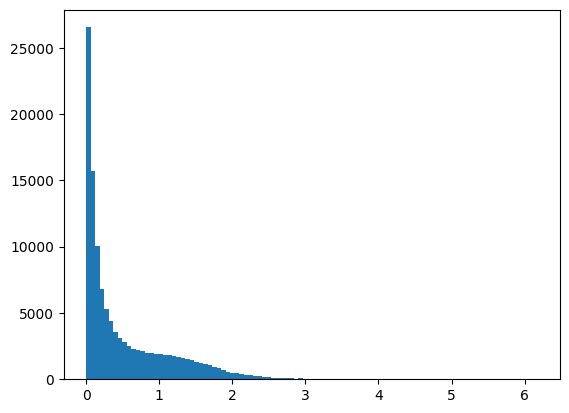

In [11]:
plt.hist(Z[Z > 0].cpu().detach().numpy(), 100);

In [9]:
thresh = 0.5

Z = F.relu(gnn(x_norm, adj_norm))
Z_pred = Z.cpu().detach().numpy() > thresh
model_saver.restore()
print(f'Final nmi = {get_nmi(thresh):.3f}')

Final nmi = 0.237


# Analyzing the results

### Visualize the adjacency matrix sorted by the communities

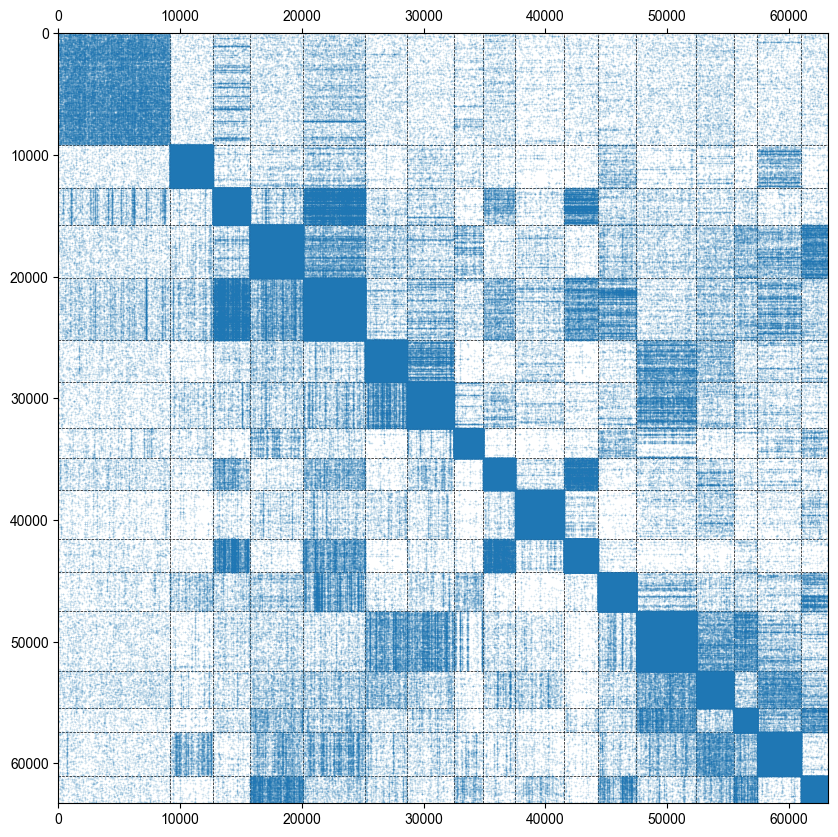

In [10]:
plt.figure(figsize=[10, 10])
z = np.argmax(Z_pred, 1)
o = np.argsort(z)
nocd.utils.plot_sparse_clustered_adjacency(A, K, z, o, markersize=0.05)

In [11]:
# Sizes of detected communities
print(Z_pred.sum(0))

[4012 3576 3117 4515 6377 3697 4477 3012 3376 4699 4788 4177 5891 5673
 4672 6377 4707]


### Iseng nampilin hasil komunitas

In [21]:
print(Z_pred.shape)

(63282, 17)


In [20]:
# Pastikan menggunakan matriks Z_pred yang terakhir (sudah biner)
# Z_pred adalah [N, K] matriks biner, di mana Z_pred[u, c] = 1 jika node u milik komunitas c.

# Konversi Matriks Komunitas Biner ke List Node
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

print(f"Total Komunitas Terdeteksi (K): {len(communities_list)}")
print("-" * 40)
print("Daftar Node per Komunitas (Matriks ke List):\n")

# Menampilkan hasil (hanya menampilkan 5 komunitas pertama dan yang tidak kosong)
count = 0
for i, community in enumerate(communities_list):
    # Memeriksa apakah komunitas tersebut memiliki anggota
    if len(community) > 0:
        print(f"Komunitas {i} (Jumlah Node: {len(community)}):")
        # Menampilkan node, dibatasi hingga 10 node pertama per komunitas untuk output yang ringkas
        if len(community) > 10:
            print(f"  {community[:10]} ... [Total {len(community)} node]")
        else:
            print(f"  {community}")
        count += 1
        
        if count >= 5 and len(communities_list) > 5:
            print("\n... (Menampilkan hanya 5 komunitas non-kosong pertama)")
            break
        
if count == 0:
    print("Tidak ada komunitas non-kosong yang terdeteksi berdasarkan ambang batas 0.5.")

Total Komunitas Terdeteksi (K): 17
----------------------------------------
Daftar Node per Komunitas (Matriks ke List):

Komunitas 0 (Jumlah Node: 14886):
  [np.int64(3), np.int64(8), np.int64(10), np.int64(16), np.int64(18), np.int64(19), np.int64(22), np.int64(24), np.int64(29), np.int64(30)] ... [Total 14886 node]
Komunitas 1 (Jumlah Node: 15624):
  [np.int64(1), np.int64(4), np.int64(6), np.int64(21), np.int64(25), np.int64(27), np.int64(30), np.int64(34), np.int64(43), np.int64(44)] ... [Total 15624 node]
Komunitas 2 (Jumlah Node: 17767):
  [np.int64(4), np.int64(6), np.int64(8), np.int64(13), np.int64(20), np.int64(21), np.int64(24), np.int64(25), np.int64(26), np.int64(31)] ... [Total 17767 node]
Komunitas 3 (Jumlah Node: 18428):
  [np.int64(1), np.int64(2), np.int64(5), np.int64(12), np.int64(14), np.int64(15), np.int64(17), np.int64(26), np.int64(27), np.int64(29)] ... [Total 18428 node]
Komunitas 4 (Jumlah Node: 19885):
  [np.int64(0), np.int64(2), np.int64(7), np.int64(13),

In [14]:
import numpy as np

# Konversi Matriks Komunitas Biner ke List Indeks Node
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

# FIX: PENTING! Konversi node_names menjadi array NumPy untuk advanced indexing
if not isinstance(node_names, np.ndarray):
    node_names = np.array(node_names)

print(f"Total Komunitas Terdeteksi (K): {len(communities_list)}")
print("-" * 60)
print("Daftar Nama Node per Komunitas:\n")

# Fungsi untuk memetakan indeks ke nama
def map_indices_to_names(index_list, names_array):
    # Baris ini sekarang akan bekerja karena names_array adalah array NumPy
    return names_array[index_list]

count = 0
for i, community_indices in enumerate(communities_list):
    # Hanya memproses komunitas yang memiliki anggota
    if len(community_indices) > 0:
        
        # --- Lakukan Pemetaan dari Indeks ke Nama ---
        community_names = map_indices_to_names(community_indices, node_names)

        print(f"Komunitas {i} (Jumlah Node: {len(community_names)}):")
        
        # Menampilkan output dengan batas 10 nama
        if len(community_names) > 10:
            # Mengonversi 10 nama pertama menjadi list agar mudah dicetak
            first_ten_names = community_names[:10].tolist() 
            print(f"  {first_ten_names} ... [Total {len(community_names)} node]")
        else:
            print(f"  {community_names.tolist()}")
        
        count += 1
        
        if count >= 5 and len(communities_list) > 5:
            print("\n... (Menampilkan hanya 5 komunitas non-kosong pertama)")
            break

if count == 0:
    print("Tidak ada komunitas non-kosong yang terdeteksi.")

Total Komunitas Terdeteksi (K): 17
------------------------------------------------------------
Daftar Nama Node per Komunitas:

Komunitas 0 (Jumlah Node: 4012):
  ['0007426B', '0008E20B', '000DD2D3', '00111C67', '001A7CDC', '001AB681', '0023E1BE', '00281398', '0028F0B0', '003B39E4'] ... [Total 4012 node]
Komunitas 1 (Jumlah Node: 3576):
  ['0026425E', '002A43C2', '00482AC9', '00525B12', '007A0B3C', '007EAF35', '00841A9C', '00A154F9', '00E866E2', '01030A87'] ... [Total 3576 node]
Komunitas 2 (Jumlah Node: 3117):
  ['00066834', '00070BBC', '0012957A', '001592D5', '001E801D', '003F7126', '005ABC5E', '006A694F', '007B41FD', '00901C44'] ... [Total 3117 node]
Komunitas 3 (Jumlah Node: 4515):
  ['000D9B73', '0015CDB0', '001C9D2F', '00258881', '002AD385', '002FD26C', '003B9DA3', '00418850', '004B36E2', '004F22F8'] ... [Total 4515 node]
Komunitas 4 (Jumlah Node: 6377):
  ['0010F142', '00144669', '0015CDB0', '001D63DE', '002CE585', '003363D0', '003435F4', '00344626', '003685DE', '0036BAC8'] ...

### Quantify quality of the communities based on unsupervised metrics.

Metrics:
* **Coverage**: what percentage of the edges is explained by at least one community? (i.e. if $(u, v)$ is an edge, both nodes share at least one community) Higher is better.
$$\textrm{Coverage}(C_1, ..., C_K) = \frac{1}{|E|}\sum_{u, v \in E} \mathbb{1}[z_u^T z_v > 0]$$


* **Density**: average density of the detected communities (weighted by community size). Higher is better.

$$\rho(C) = \frac{\text{# existing edges in $C$}}{\text{# of possible edges in $C$}}$$

$$\textrm{AvgDensity}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \rho(C_i) \cdot |C_i|$$


* **Conductance**: average conductance of the detected communities (weighted by community size). Lower is better.

$$\textrm{outside}(C) = \sum_{u \in C, v \notin C} A_{uv}$$

$$\textrm{inside}(C) = \sum_{u \in C, v \in C, v \ne u} A_{uv}$$

$$\textrm{Conductance}(C) = \frac{\textrm{outside}(C)}{\textrm{inside}(C) + \textrm{outside}(C)}$$

$$\textrm{AvgConductance}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \textrm{Conductance}(C_i) \cdot |C_i|$$


* **Clustering coefficient**: average clustering coefficient of the detected communities (weighted by community size). Higher is better.

$$\textrm{ClustCoef}(C) = \frac{\text{# existing triangles in $C$}}{\text{# of possible triangles in $C$}}$$

$$\textrm{AvgClustCoef}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \textrm{ClustCoef}(C_i) \cdot |C_i|$$

Clustering coefficient & density of the entire graph

In [17]:
density_baseline = A.nnz / (N**2 - N)
num_triangles = (A @ A @ A).diagonal().sum() / 6
num_possible_triangles = (N - 2) * (N - 1) * N / 6
clust_coef_baseline = num_triangles / num_possible_triangles
print(f'Background (over the entire graph):\n'
      f' - density    = {density_baseline:.3e}\n'
      f' - clust_coef = {clust_coef_baseline:.3e}')

Background (over the entire graph):
 - density    = 2.510e-04
 - clust_coef = 3.608e-08


In [18]:
metrics = nocd.metrics.evaluate_unsupervised(Z_gt, A)
print(f"Ground truth communities:\n"
      f" - coverage    = {metrics['coverage']:.4f}\n"
      f" - conductance = {metrics['conductance']:.4f}\n"
      f" - density     = {metrics['density']:.3e}\n"
      f" - clust_coef  = {metrics['clustering_coef']:.3e}")

Ground truth communities:
 - coverage    = 0.9544
 - conductance = 0.3250
 - density     = 1.923e-03
 - clust_coef  = 3.461e-06


In [19]:
metrics = nocd.metrics.evaluate_unsupervised(Z_pred, A)
print(f"Predicted communities:\n"
      f" - coverage    = {metrics['coverage']:.4f}\n"
      f" - conductance = {metrics['conductance']:.4f}\n"
      f" - density     = {metrics['density']:.3e}\n"
      f" - clust_coef  = {metrics['clustering_coef']:.3e}")

Predicted communities:
 - coverage    = 0.9241
 - conductance = 0.2151
 - density     = 2.529e-03
 - clust_coef  = 4.630e-06


The detected partition has lower conductance / higher density / higher clustering coefficient than the GT communities.

Tambahan Sendiri

In [ ]:
# Contoh Penggunaan (Simulasi data)
# N=4 nodes, C=2 communities
# Jaringan (0-1, 1-2, 2-3)
adj = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0]
])

# Komunitas 1: {0, 1, 2}, Komunitas 2: {1, 2, 3} (Tumpang tindih di 1 dan 2)
memb_matrix = np.array([
    [1, 0], # Node 0
    [1, 1], # Node 1 (Overlapping)
    [1, 1], # Node 2 (Overlapping)
    [0, 1]  # Node 3
])

# Link Membership untuk Link Modularity (asumsi Link (1,2) milik dua komunitas)
link_memb = {
    (0, 1): [0],
    (1, 2): [0, 1], # Tumpang tindih link
    (2, 3): [1]
}

# Link Modularity menggunakan indeks yang sesuai dengan adj_matrix
link_memb_adj = {}
for (i, j), comms in link_memb.items():
    # Pastikan urutan tuple sesuai (i < j) untuk konsistensi
    if i < j:
        link_memb_adj[(i, j)] = comms
    else:
        link_memb_adj[(j, i)] = comms


metrics = nocd.metrics.evaluate_modularity(adj, memb_matrix, link_memb_adj)
print(f"Contoh (Overlapping Modularity): {metrics['overlapping_modularity']:.4f}")
print(f"Contoh (Link Modularity): {metrics['link_modulrity']:.4f}\n")



Contoh Q_ov (Overlapping Modularity): 0.1667
Contoh Q_L (Link Modularity): 0.5556



Note : 
- Overllaping Modularity = Semakin mendekati 1, semakin bagus, tandanya yang ditemukan bagus
- Link Modularity = Semakin mendekati 1, semakin bagus, tandanya yang ditemukan bagus
